In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Sannolikhetsbaserat neuralt nät

Här implementerar vi ett neuralt nät vars prediktion är en normalfördelning. Vi tränar det på brusig data som vi skapar, där olika områden har olika mycket brus. Kan vi få modellen att lära sig förutsäga hur bruset ser ut?

# Exempeldata

* Vi simulerar xdata uniformt i intervallet [-1, 1].
* Vi låter y vara en sinusfunktion beroende på xdata, där brus skalas med värdena i xdata.

In [2]:
xdata = np.random.uniform(-1, 1, size=(1000,))
ydata = np.sin(3 * xdata) + xdata * np.random.uniform(-1, 1, size=(1000,))

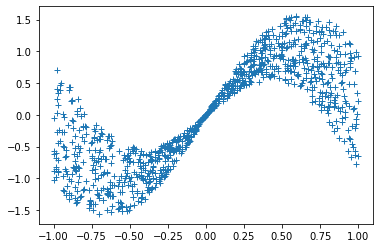

In [3]:
plt.plot(xdata, ydata, '+')

# PyTorch dataladdare

Vi skapar en PyTorch dataladdare som skapar brusig data. Se att vi använder `__getitem__` för att generera data med viss index. Och att klassen NoisyData ärver från `torch.utils.data.Dataset`, vilket gör att vi kan använda PyTorchs inbyggda dataladdare.

In [4]:
class NoisyData(torch.utils.data.Dataset):
    def __init__(self, scale=1):
        self.xdata = np.random.uniform(-1, 1, size=(1000,))
        self.ydata = np.sin(3 * self.xdata) + self.xdata * np.random.uniform(-1, 1, size=(1000,)) * scale
        
    def __getitem__(self, idx):
        # Lämna tillbaka data nummer idx
        return (self.xdata[idx], self.ydata[idx])
    
    def __len__(self):
        return self.xdata.shape[0]

In [5]:
dataset = NoisyData()
train_loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=False)

# Modell

Vi skapar en modell som förutsäger en normalfördelning. Vi använder två lager med ReLU-aktiveringar och en lager med två output-noder, en för medelvärdet och en för standardavvikelsen.

In [6]:
model = torch.nn.Sequential(
    torch.nn.Linear(1, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 2)
    )

In [7]:
opt = torch.optim.Adam(model.parameters(), lr=0.001)

# Träning

In [8]:
epochs = 50

In [9]:
fel_loss = []
val_loss = []

for epoch in range(epochs):
    totalt_fel = 0

    # Loopa över alla batchar
    for x, ytarget in train_loader:
        y = model(x.unsqueeze(1).float())

        # Dela upp y i två delar, en för medelvärdet och en för standardavvikelsen
        mean = y[:, 0]
        t = y[:, 1]
        
        # Beräkna felet
        fel = (1/2) * (ytarget - mean)**2 / torch.exp(2*t) + t # -ln(p(y|x, f))

        # Medelvärdet av felet för en batch
        fel = fel.mean()

        # Lägg till felet för denna batch till det totala felet
        totalt_fel += fel.item()

        # Beräkna gradienten och uppdatera vikterna
        opt.zero_grad()
        fel.backward()
        opt.step()
        
    fel_loss.append(totalt_fel)

    if epoch % 1 == 0:
        # Beräkna felet på valideringsdatan
        val_x, val_y = next(iter(val_loader))
        y = model(val_x.unsqueeze(1).float())
        mean = y[:, 0]
        t = y[:, 1]
        fel = (1/2) * (val_y - mean)**2 / torch.exp(2*t) + t
        fel = fel.mean()
        val_loss.append(fel.item())
        print(f"Epoch {epoch} Fel: {totalt_fel} Valideringsfel: {fel.item()}")


Epoch 0 Fel: 12.61574469583826 Valideringsfel: 0.31365803424561495
Epoch 1 Fel: 7.676342422524446 Valideringsfel: 0.16619593273297317
Epoch 2 Fel: 3.2036241405412227 Valideringsfel: 0.024240137312576765
Epoch 3 Fel: -0.6534699559359728 Valideringsfel: -0.08781737559118596
Epoch 4 Fel: -4.164341802211226 Valideringsfel: -0.19446235125866143
Epoch 5 Fel: -7.076671867014212 Valideringsfel: -0.24510251469809158
Epoch 6 Fel: -8.539586788624355 Valideringsfel: -0.2813079213058175
Epoch 7 Fel: -10.019726342580013 Valideringsfel: -0.33710231864208884
Epoch 8 Fel: -11.888335286733266 Valideringsfel: -0.4055867339962218
Epoch 9 Fel: -14.03208018832421 Valideringsfel: -0.4838691722204216
Epoch 10 Fel: -16.8227062744003 Valideringsfel: -0.5669474259077594
Epoch 11 Fel: -19.6043808026093 Valideringsfel: -0.6585648343139847
Epoch 12 Fel: -21.84623857309427 Valideringsfel: -0.7042076653322216
Epoch 13 Fel: -23.953801295323192 Valideringsfel: -0.7763525020073851
Epoch 14 Fel: -25.363549792472753 Valid

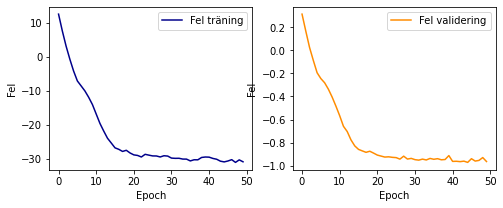

In [10]:
#Plotta resultatet
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(fel_loss, label='Fel träning', color = 'darkblue')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Fel')
plt.subplot(1, 2, 2)
plt.plot(val_loss, label='Fel validering', color='darkorange')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Fel')
plt.show()

# Evaluering

Låt oss se hur väl modellen kan förutsäga bruset. Vi plottar förutsägelserna och jämför med det sanna bruset.

In [11]:
xtest = np.arange(-1.1, 1.1, 0.01)
ytest = model(torch.tensor(xtest).unsqueeze(1).float())
ytest.shape

torch.Size([220, 2])

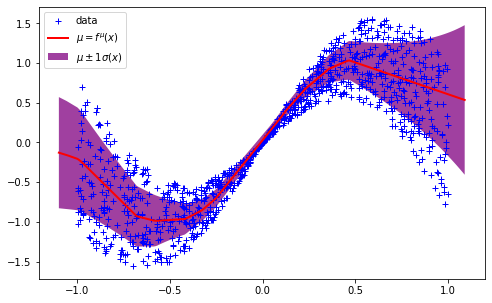

In [12]:
ytest_np = ytest.detach().numpy() # Omvandla till numpy
mean = ytest_np[:, 0] # Medelvärdet
std = np.exp(ytest_np[:, 1]) # Standardavvikelsen

plt.figure(figsize = (8,5))
plt.fill_between(xtest, mean - std, mean + std, facecolor="purple", alpha=0.75, label="$\mu \pm 1 \sigma(x)$")
plt.plot(xdata, ydata, 'b+', label="data")
plt.plot(xtest, mean, 'r-', linewidth=2, label="$\mu = f^\mu(x)$")
plt.legend()

Vi ser att modellen har lyckats att lära sig den $x$-beroende distributionen för $y$ väl!

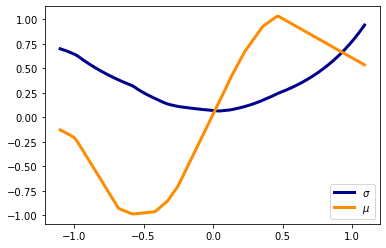

In [13]:
plt.figure(figsize = (6, 4))
plt.plot(xtest, std, label="$\sigma$", color='darkblue', linewidth=3)
plt.plot(xtest, mean, label="$\mu$", color='darkorange', linewidth=3)
plt.legend(loc = 'lower right')
plt.show()

* Lägst standardavvikelse i mitten, där bruset är som minst.
* Högre standardavvikelse i kanterna, där bruset är som mest.
* Medelvärdet följer sinusfunktionen väl.